In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings

warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

plt.rcParams['figure.figsize'] = (10, 5)

In [3]:
FILE_PATH = "synthetic_D003.csv"
CHUNK_SIZE = 200_000
SAMPLE_PER_CHUNK = 10_000
MAX_CHUNKS = 50   # можно уменьшить/увеличить по мощности ноутбука

sample_parts = []
total_rows_seen = 0

for i, chunk in enumerate(pd.read_csv(FILE_PATH, chunksize=CHUNK_SIZE)):
    total_rows_seen += len(chunk)
    
    # если чанк меньше нужного sample, берем весь
    take_n = min(SAMPLE_PER_CHUNK, len(chunk))
    sampled_chunk = chunk.sample(n=take_n, random_state=42)
    sample_parts.append(sampled_chunk)
    
    if i + 1 >= MAX_CHUNKS:
        break

df = pd.concat(sample_parts, ignore_index=True)

print("Количество строк в выборке:", len(df))
print("Просмотрено строк из файла:", total_rows_seen)
df.head()

Количество строк в выборке: 500000
Просмотрено строк из файла: 10000000


,TE,K,KVART,PARC,RAZD,DATE_Z,KOL_PR,KOD_PRN,KOD_TU,CUPL_POTR,EDIZM,UPLACH,STOIM,CELPOK,MESTPOK,PRIMECH,STOIM4,CHARDAY,ZT,NOMER,god,KOD_INT
0,35,2,2,2,2.0,2020-05-25,8.0,NaN,1171004.0,2.927,166.0,47.0,407.0,1.0,1.0,NaN,17.0,NaN,1.0,51919,2020,NaN
1,63,2,2,1,2.0,2020-07-06,10.0,NaN,1113003.0,2.467,166.0,1818.0,2510.0,1.0,1.0,NaN,0.0,NaN,NaN,35661,2020,NaN
2,11,1,3,2,2.0,2020-07-26,2.0,NaN,1171011.0,1.064,166.0,93.0,497.0,1.0,2.0,NaN,0.0,NaN,NaN,41308,2020,NaN
3,59,1,4,1,2.0,2020-12-01,2.0,NaN,1122203.0,0.022,NaN,0.0,283.0,1.0,1.0,NaN,NaN,NaN,NaN,32213,2020,NaN
4,11,1,4,2,2.0,2020-09-06,2.0,NaN,1121504.0,0.840,166.0,828.0,1391.0,1.0,NaN,NaN,0.0,NaN,NaN,22401,2020,NaN


In [4]:
print("Размер датафрейма:", df.shape)
print("\nТипы данных:")
print(df.dtypes)

print("\nПервые строки:")
display(df.head())

print("\nПропуски:")
display(df.isna().sum().sort_values(ascending=False).head(30))

Размер датафрейма: (500000, 22)

Типы данных:
TE             int64
K              int64
KVART          int64
PARC           int64
RAZD         float64
DATE_Z        object
KOL_PR        object
KOD_PRN       object
KOD_TU       float64
CUPL_POTR    float64
EDIZM        float64
UPLACH       float64
STOIM        float64
CELPOK       float64
MESTPOK      float64
PRIMECH       object
STOIM4       float64
CHARDAY      float64
ZT            object
NOMER          int64
god            int64
KOD_INT      float64
dtype: object

Первые строки:


,TE,K,KVART,PARC,RAZD,DATE_Z,KOL_PR,KOD_PRN,KOD_TU,CUPL_POTR,EDIZM,UPLACH,STOIM,CELPOK,MESTPOK,PRIMECH,STOIM4,CHARDAY,ZT,NOMER,god,KOD_INT
0,35,2,2,2,2.0,2020-05-25,8.0,NaN,1171004.0,2.927,166.0,47.0,407.0,1.0,1.0,NaN,17.0,NaN,1.0,51919,2020,NaN
1,63,2,2,1,2.0,2020-07-06,10.0,NaN,1113003.0,2.467,166.0,1818.0,2510.0,1.0,1.0,NaN,0.0,NaN,NaN,35661,2020,NaN
2,11,1,3,2,2.0,2020-07-26,2.0,NaN,1171011.0,1.064,166.0,93.0,497.0,1.0,2.0,NaN,0.0,NaN,NaN,41308,2020,NaN
3,59,1,4,1,2.0,2020-12-01,2.0,NaN,1122203.0,0.022,NaN,0.0,283.0,1.0,1.0,NaN,NaN,NaN,NaN,32213,2020,NaN
4,11,1,4,2,2.0,2020-09-06,2.0,NaN,1121504.0,0.840,166.0,828.0,1391.0,1.0,NaN,NaN,0.0,NaN,NaN,22401,2020,NaN



Пропуски:


KOD_PRN      493147
PRIMECH      485079
KOD_INT      444189
CHARDAY      424502
ZT           388549
MESTPOK      199309
STOIM4        80351
EDIZM         78931
CELPOK        76026
KOD_TU        76016
STOIM         17131
UPLACH        15698
CUPL_POTR       442
KOL_PR          236
RAZD              4
DATE_Z            3
TE                0
K                 0
KVART             0
PARC              0
NOMER             0
god               0
dtype: int64

In [5]:
key_cols = ['DATE_Z', 'STOIM', 'CUPL_POTR', 'MESTPOK', 'K', 'TE', 'KOD_TU']

for col in key_cols:
    if col in df.columns:
        print(f"\n===== {col} =====")
        print("Пропуски:", df[col].isna().sum())
        print("Уникальных значений:", df[col].nunique(dropna=True))
        print(df[col].value_counts(dropna=False).head(10))


===== DATE_Z =====
Пропуски: 3
Уникальных значений: 995
DATE_Z
2021-01-01    852
2021-01-04    778
2021-01-05    751
2021-01-03    742
2020-12-27    742
2021-12-24    725
2020-12-25    724
2021-12-27    716
2021-01-02    715
2020-04-09    711
Name: count, dtype: int64

===== STOIM =====
Пропуски: 17131
Уникальных значений: 8453
STOIM
0.0    17950
NaN    17131
1.0     7227
2.0     4267
3.0     3397
4.0     2818
5.0     2336
6.0     2117
7.0     1893
8.0     1782
Name: count, dtype: int64

===== CUPL_POTR =====
Пропуски: 442
Уникальных значений: 9382
CUPL_POTR
0.000    6249
0.001    4448
0.002    3276
0.003    2687
0.004    2337
0.005    2054
0.006    1992
0.007    1743
0.008    1743
0.009    1600
Name: count, dtype: int64

===== MESTPOK =====
Пропуски: 199309
Уникальных значений: 4
MESTPOK
1.0    222303
NaN    199309
2.0     46475
3.0     30152
9.0      1761
Name: count, dtype: int64

===== K =====
Пропуски: 0
Уникальных значений: 2
K
1    265077
2    234923
Name: count, dtype: int64



In [6]:
work = df.copy()

In [7]:
work['DATE_Z'] = pd.to_datetime(work['DATE_Z'], errors='coerce')

print("Минимальная дата:", work['DATE_Z'].min())
print("Максимальная дата:", work['DATE_Z'].max())
print("Пропуски в DATE_Z:", work['DATE_Z'].isna().sum())

Минимальная дата: 2020-04-01 00:00:00
Максимальная дата: 2022-12-27 00:00:00
Пропуски в DATE_Z: 3


In [8]:
work = work.dropna(subset=['DATE_Z', 'STOIM', 'CUPL_POTR', 'TE'])

print("Размер после удаления пропусков в ключевых полях:", work.shape)

Размер после удаления пропусков в ключевых полях: (482442, 22)


In [9]:
numeric_cols = ['STOIM', 'CUPL_POTR', 'MESTPOK', 'K', 'TE', 'KOD_TU']

for col in numeric_cols:
    if col in work.columns:
        work[col] = pd.to_numeric(work[col], errors='coerce')

print(work[numeric_cols].dtypes)

STOIM        float64
CUPL_POTR    float64
MESTPOK      float64
K              int64
TE             int64
KOD_TU       float64
dtype: object


In [10]:
# стоимость и объем должны быть положительными
work = work[(work['STOIM'] > 0) & (work['CUPL_POTR'] > 0)]

print("Размер после удаления STOIM <= 0 и CUPL_POTR <= 0:", work.shape)

Размер после удаления STOIM <= 0 и CUPL_POTR <= 0: (458517, 22)


In [11]:
print("MESTPOK value counts:")
print(work['MESTPOK'].value_counts(dropna=False).head(20))

print("\nK value counts:")
print(work['K'].value_counts(dropna=False).head(20))

MESTPOK value counts:
MESTPOK
1.0    206083
NaN    183776
2.0     40363
3.0     26858
9.0      1437
Name: count, dtype: int64

K value counts:
K
1    244189
2    214328
Name: count, dtype: int64


In [12]:
location_map = {
    1: 'Город',
    2: 'Село'
}

work['Location'] = work['MESTPOK'].map(location_map)
work['Location'] = work['Location'].fillna('Неизвестно')

print(work['Location'].value_counts())

Location
Неизвестно    212071
Город         206083
Село           40363
Name: count, dtype: int64


In [13]:
work['Year'] = work['DATE_Z'].dt.year
work['Month'] = work['DATE_Z'].dt.month
work['Month_Name'] = work['DATE_Z'].dt.month_name()

In [14]:
work['price_per_unit'] = work['STOIM'] / work['CUPL_POTR']

print(work[['STOIM', 'CUPL_POTR', 'price_per_unit']].head())

    STOIM  CUPL_POTR  price_per_unit
0   407.0      2.927      139.050222
1  2510.0      2.467     1017.430077
2   497.0      1.064      467.105263
3   283.0      0.022    12863.636364
4  1391.0      0.840     1655.952381


In [15]:
work['Spending_Segment'] = pd.qcut(
    work['STOIM'],
    q=3,
    labels=['Низкие расходы', 'Средние расходы', 'Высокие расходы']
)

print(work['Spending_Segment'].value_counts())

Spending_Segment
Низкие расходы     153033
Высокие расходы    152812
Средние расходы    152672
Name: count, dtype: int64


In [16]:
display(work[['STOIM', 'CUPL_POTR', 'price_per_unit']].describe())

,STOIM,CUPL_POTR,price_per_unit
count,458517.000000,458517.000000,4.585170e+05
mean,942.486569,1.164813,8.207216e+03
std,1211.005839,1.448786,4.721597e+04
min,1.000000,0.001000,1.682369e-01
25%,155.000000,0.180000,2.630992e+02
50%,538.000000,0.644000,8.848507e+02
75%,1273.000000,1.602000,2.766423e+03
max,21352.000000,24.863000,2.757000e+06


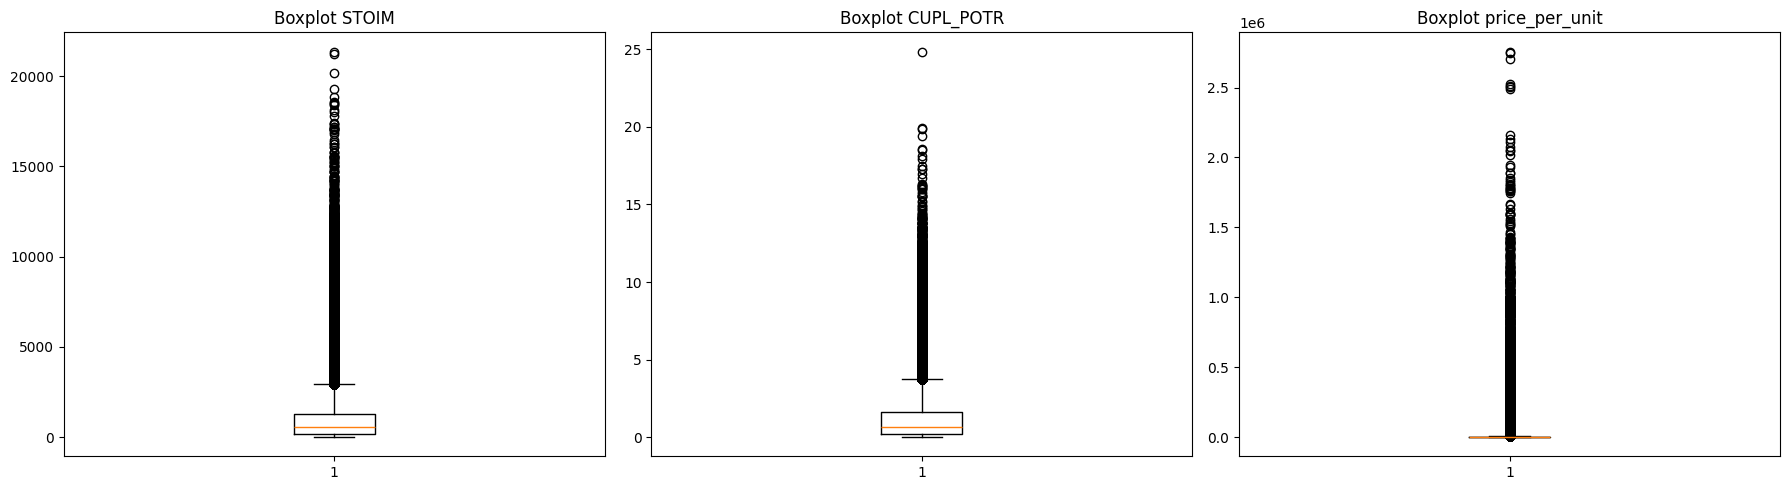

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].boxplot(work['STOIM'].dropna())
axes[0].set_title('Boxplot STOIM')

axes[1].boxplot(work['CUPL_POTR'].dropna())
axes[1].set_title('Boxplot CUPL_POTR')

axes[2].boxplot(work['price_per_unit'].dropna())
axes[2].set_title('Boxplot price_per_unit')

plt.tight_layout()
plt.show()

In [18]:
viz = work.copy()

stoim_upper = viz['STOIM'].quantile(0.99)
cupl_upper = viz['CUPL_POTR'].quantile(0.99)
ppu_upper = viz['price_per_unit'].quantile(0.99)

viz = viz[
    (viz['STOIM'] <= stoim_upper) &
    (viz['CUPL_POTR'] <= cupl_upper) &
    (viz['price_per_unit'] <= ppu_upper)
]

print("Размер набора для визуализации:", viz.shape)

Размер набора для визуализации: (445769, 28)


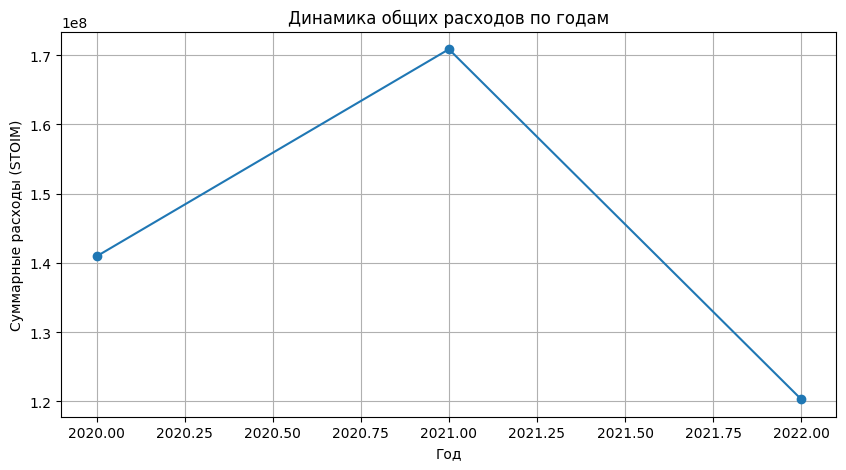

Этот график показывает, как менялся общий объем расходов по годам.
Если есть рост, это может быть связано с инфляцией, ростом цен или увеличением объема потребления.


In [19]:
yearly_expenses = work.groupby('Year', as_index=False)['STOIM'].sum()

plt.plot(yearly_expenses['Year'], yearly_expenses['STOIM'], marker='o')
plt.title('Динамика общих расходов по годам')
plt.xlabel('Год')
plt.ylabel('Суммарные расходы (STOIM)')
plt.grid(True)
plt.show()

yearly_expenses
print("Этот график показывает, как менялся общий объем расходов по годам.")
print("Если есть рост, это может быть связано с инфляцией, ростом цен или увеличением объема потребления.")

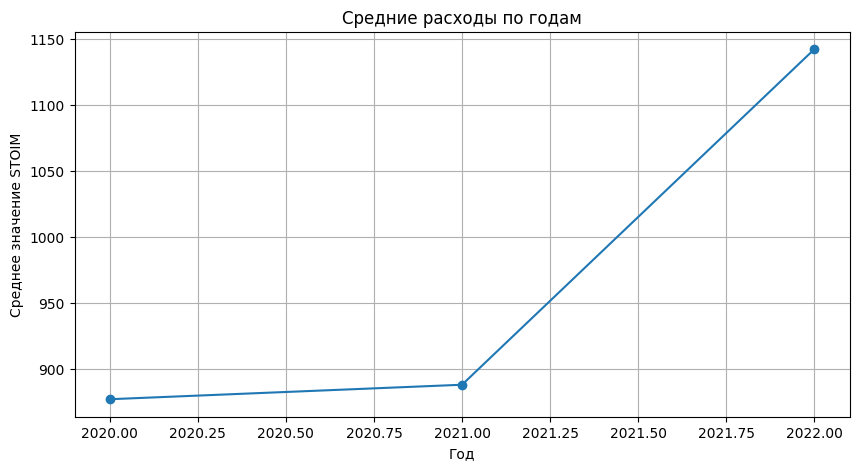

,Year,STOIM
0,2020,876.938939
1,2021,887.917563
2,2022,1142.170356


In [20]:
yearly_mean = work.groupby('Year', as_index=False)['STOIM'].mean()

plt.plot(yearly_mean['Year'], yearly_mean['STOIM'], marker='o')
plt.title('Средние расходы по годам')
plt.xlabel('Год')
plt.ylabel('Среднее значение STOIM')
plt.grid(True)
plt.show()

yearly_mean

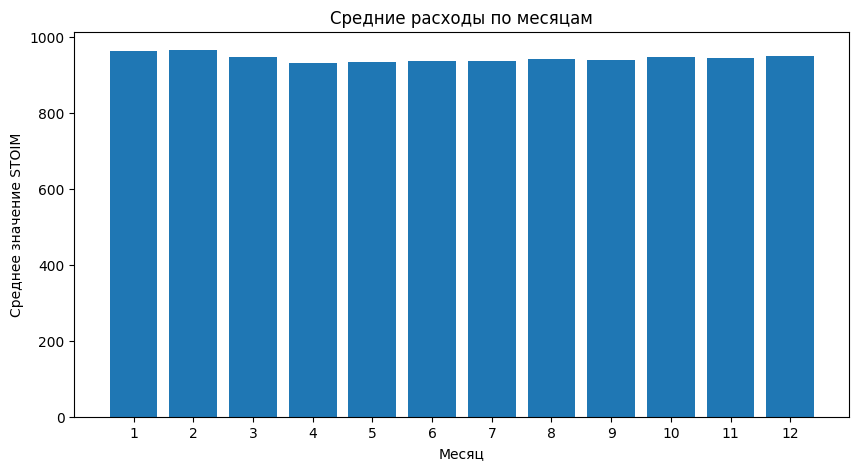

Если видны пики в отдельных месяцах, можно говорить о сезонности расходов.
Например, зимой могут расти траты из-за повышения цен, праздничного спроса или особенностей потребления.


In [21]:
monthly_mean = work.groupby('Month', as_index=False)['STOIM'].mean()

plt.bar(monthly_mean['Month'], monthly_mean['STOIM'])
plt.title('Средние расходы по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Среднее значение STOIM')
plt.xticks(monthly_mean['Month'])
plt.show()

monthly_mean

print("Если видны пики в отдельных месяцах, можно говорить о сезонности расходов.")
print("Например, зимой могут расти траты из-за повышения цен, праздничного спроса или особенностей потребления.")

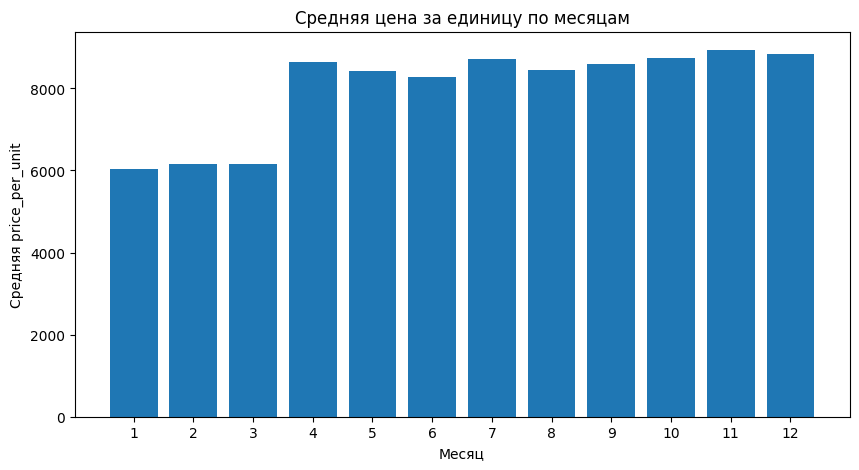

Этот график лучше отражает изменение условной цены, чем просто STOIM.
Он помогает понять, действительно ли дорожают товары, а не только растет общий объем покупок.


In [22]:
monthly_price = work.groupby('Month', as_index=False)['price_per_unit'].mean()

plt.bar(monthly_price['Month'], monthly_price['price_per_unit'])
plt.title('Средняя цена за единицу по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Средняя price_per_unit')
plt.xticks(monthly_price['Month'])
plt.show()

monthly_price

print("Этот график лучше отражает изменение условной цены, чем просто STOIM.")
print("Он помогает понять, действительно ли дорожают товары, а не только растет общий объем покупок.")

,Location,STOIM
0,Город,1019.329183
1,Село,597.913262


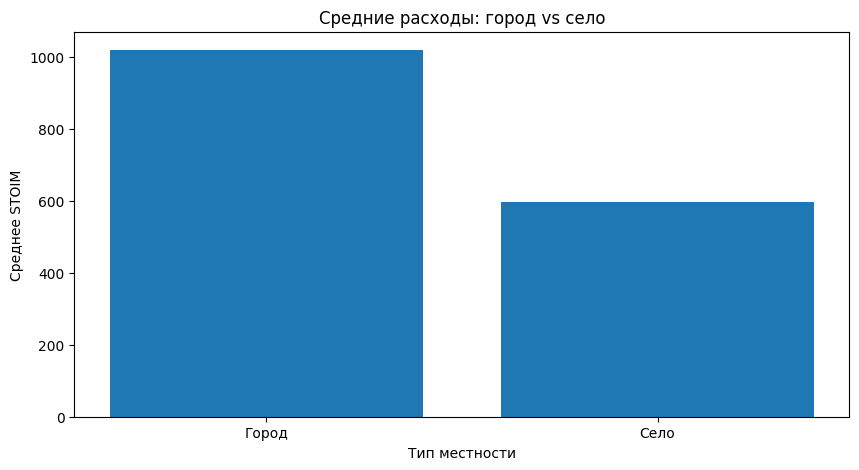

In [23]:
loc_mean = work[work['Location'] != 'Неизвестно'].groupby('Location', as_index=False)['STOIM'].mean()
display(loc_mean)

plt.bar(loc_mean['Location'], loc_mean['STOIM'])
plt.title('Средние расходы: город vs село')
plt.xlabel('Тип местности')
plt.ylabel('Среднее STOIM')
plt.show()

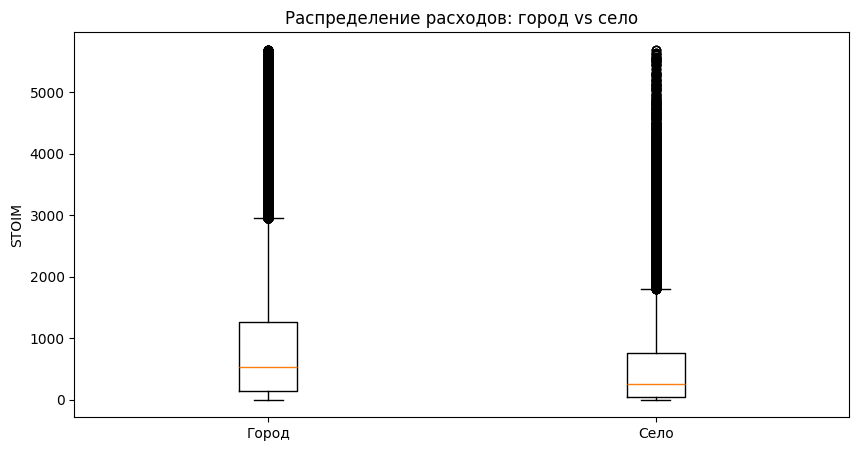

Boxplot показывает не только среднее, но и разброс, медиану и выбросы.
Так можно увидеть, где расходы стабильнее, а где сильнее разбросаны.


In [24]:
plot_data = viz[viz['Location'] != 'Неизвестно']

plt.boxplot(
    [plot_data[plot_data['Location'] == 'Город']['STOIM'],
     plot_data[plot_data['Location'] == 'Село']['STOIM']],
    labels=['Город', 'Село']
)
plt.title('Распределение расходов: город vs село')
plt.ylabel('STOIM')
plt.show()

print("Boxplot показывает не только среднее, но и разброс, медиану и выбросы.")
print("Так можно увидеть, где расходы стабильнее, а где сильнее разбросаны.")

,Location,price_per_unit
0,Город,5019.508626
1,Село,6704.414280


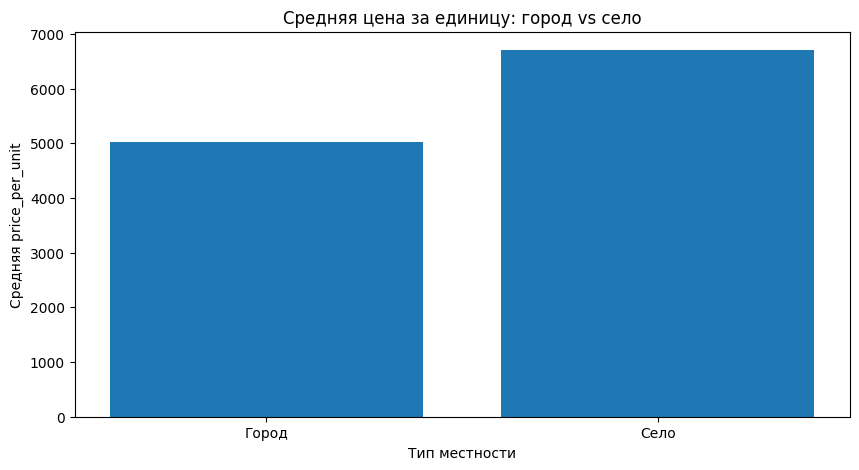

In [25]:
loc_ppu = work[work['Location'] != 'Неизвестно'].groupby('Location', as_index=False)['price_per_unit'].mean()
display(loc_ppu)

plt.bar(loc_ppu['Location'], loc_ppu['price_per_unit'])
plt.title('Средняя цена за единицу: город vs село')
plt.xlabel('Тип местности')
plt.ylabel('Средняя price_per_unit')
plt.show()

,KOD_TU,STOIM
14,1113003.0,27505738.0
109,1141101.0,9924976.0
272,2201001.0,9924005.0
112,1141104.0,9320146.0
191,1172001.0,9059229.0
140,1161001.0,7036098.0
132,1142001.0,6794359.0
13,1113002.0,6544644.0
121,1141303.0,6191407.0
0,1111001.0,5838480.0


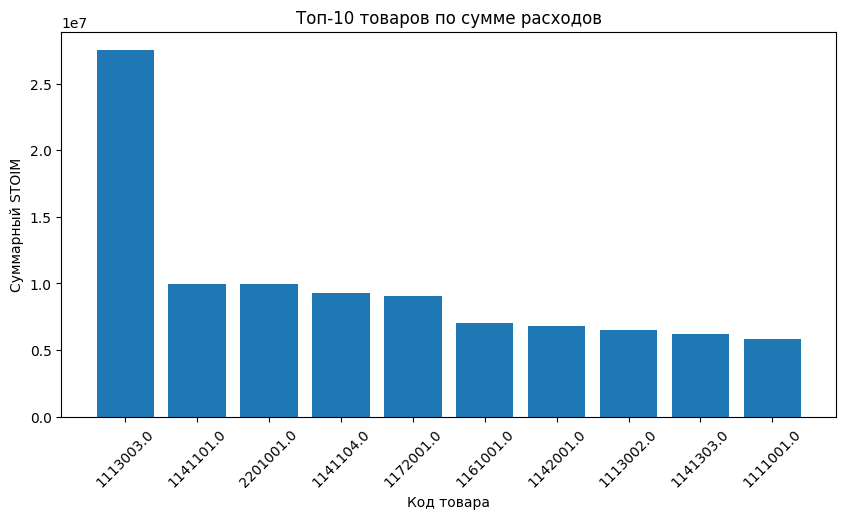

Так мы находим товары, которые дают основной вклад в суммарные расходы.
Даже без расшифровки названий кодов можно выделить самые 'дорогие' товарные группы.


In [26]:
top_goods = work.groupby('KOD_TU', as_index=False)['STOIM'].sum().sort_values('STOIM', ascending=False).head(10)

display(top_goods)

plt.bar(top_goods['KOD_TU'].astype(str), top_goods['STOIM'])
plt.title('Топ-10 товаров по сумме расходов')
plt.xlabel('Код товара')
plt.ylabel('Суммарный STOIM')
plt.xticks(rotation=45)
plt.show()

print("Так мы находим товары, которые дают основной вклад в суммарные расходы.")
print("Даже без расшифровки названий кодов можно выделить самые 'дорогие' товарные группы.")

,TE,STOIM
0,10,1159.991468
7,33,1136.350217
15,62,1120.681018
2,15,953.206555
10,43,950.846557
8,35,950.145997
9,39,949.978411
12,55,946.746779
4,23,943.450360
1,11,943.294010


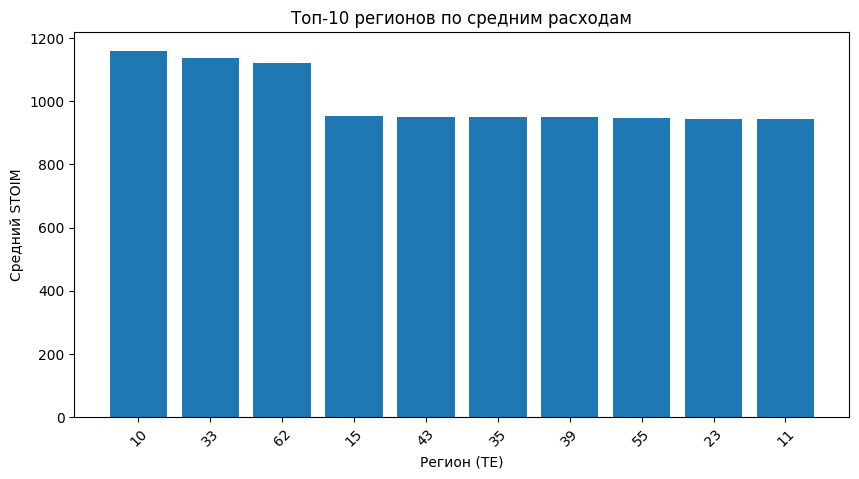

In [27]:
top_regions = work.groupby('TE', as_index=False)['STOIM'].mean().sort_values('STOIM', ascending=False).head(10)

display(top_regions)

plt.bar(top_regions['TE'].astype(str), top_regions['STOIM'])
plt.title('Топ-10 регионов по средним расходам')
plt.xlabel('Регион (TE)')
plt.ylabel('Средний STOIM')
plt.xticks(rotation=45)
plt.show()

,TE,price_per_unit
7,33,21271.030526
15,62,19934.255949
0,10,17013.626122
11,47,9112.247992
10,43,8587.747155
19,79,8483.034206
18,75,8417.116724
17,71,8380.429843
6,31,8364.464276
13,59,8342.207653


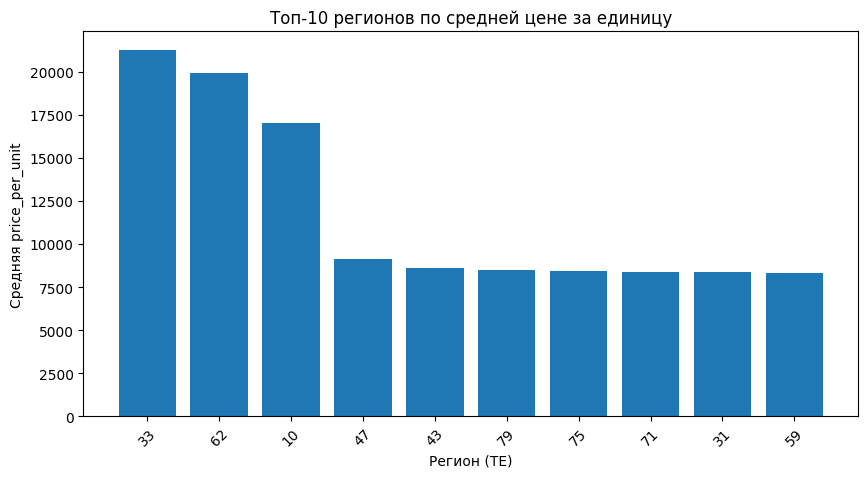

In [28]:
top_regions_ppu = work.groupby('TE', as_index=False)['price_per_unit'].mean().sort_values('price_per_unit', ascending=False).head(10)

display(top_regions_ppu)

plt.bar(top_regions_ppu['TE'].astype(str), top_regions_ppu['price_per_unit'])
plt.title('Топ-10 регионов по средней цене за единицу')
plt.xlabel('Регион (TE)')
plt.ylabel('Средняя price_per_unit')
plt.xticks(rotation=45)
plt.show()

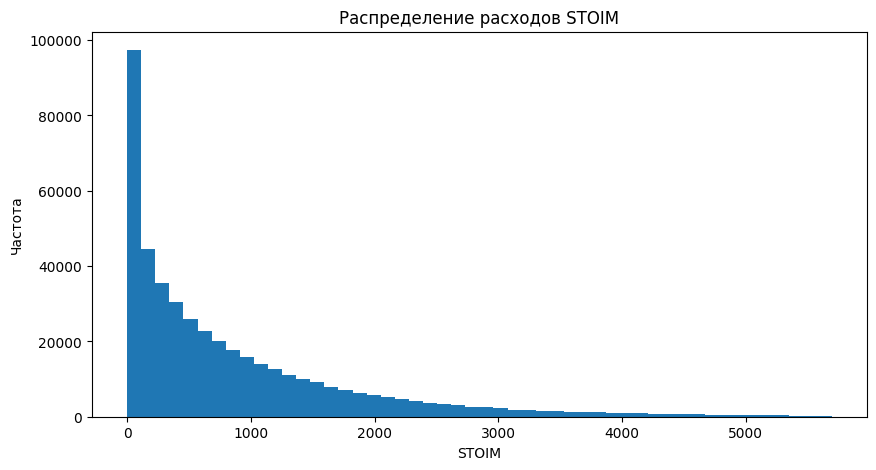

In [29]:
plt.hist(viz['STOIM'], bins=50)
plt.title('Распределение расходов STOIM')
plt.xlabel('STOIM')
plt.ylabel('Частота')
plt.show()

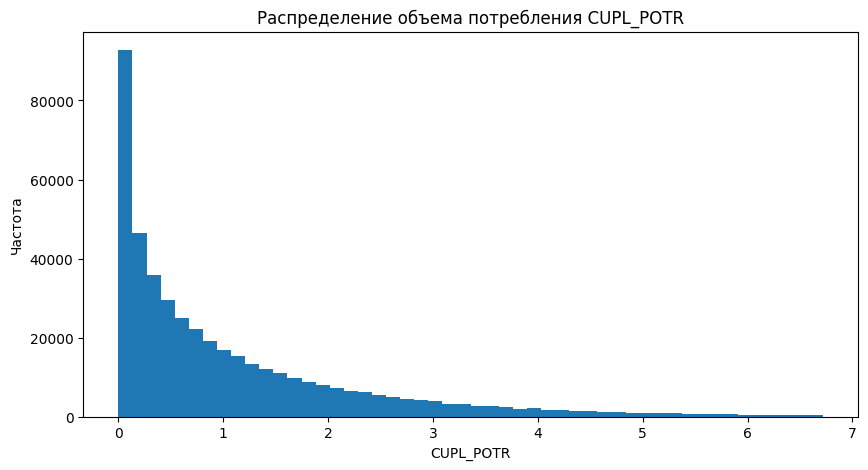

In [30]:
plt.hist(viz['CUPL_POTR'], bins=50)
plt.title('Распределение объема потребления CUPL_POTR')
plt.xlabel('CUPL_POTR')
plt.ylabel('Частота')
plt.show()

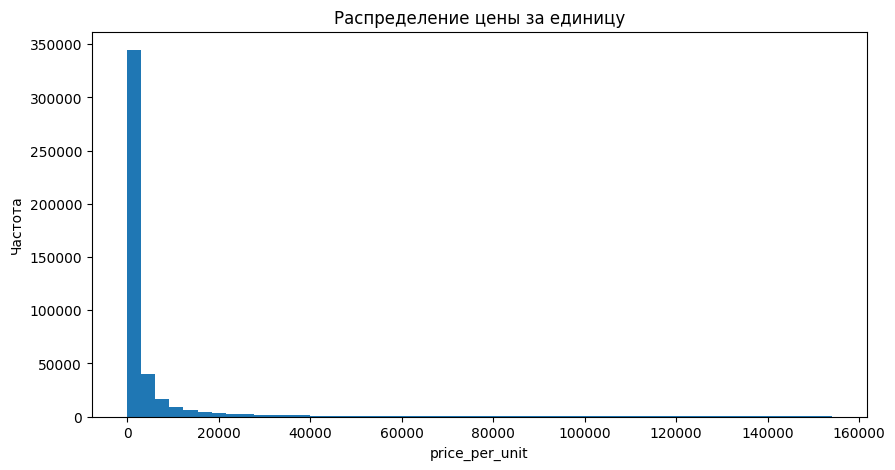

In [31]:
plt.hist(viz['price_per_unit'], bins=50)
plt.title('Распределение цены за единицу')
plt.xlabel('price_per_unit')
plt.ylabel('Частота')
plt.show()

In [32]:
stat_df = work[
    (work['Location'].isin(['Город', 'Село'])) &
    (work['STOIM'].notna()) &
    (work['CUPL_POTR'].notna()) &
    (work['price_per_unit'].notna())
].copy()

print(stat_df.shape)

(246446, 28)


In [33]:
city = stat_df[stat_df['Location'] == 'Город']['STOIM']
rural = stat_df[stat_df['Location'] == 'Село']['STOIM']

t_stat, p_val = stats.ttest_ind(city, rural, equal_var=False, nan_policy='omit')

print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: 77.67901401669268
P-value: 0.0


In [34]:
if p_val < 0.05:
    print("Различие между городом и селом статистически значимо.")
else:
    print("Статистически значимого различия между городом и селом не обнаружено.")

Различие между городом и селом статистически значимо.


In [35]:
corr, corr_p = stats.pearsonr(stat_df['CUPL_POTR'], stat_df['STOIM'])

print("Коэффициент корреляции:", corr)
print("P-value:", corr_p)
if abs(corr) >= 0.7:
    print("Связь сильная.")
elif abs(corr) >= 0.4:
    print("Связь умеренная.")
else:
    print("Связь слабая.")

Коэффициент корреляции: 0.5001773537782234
P-value: 0.0
Связь умеренная.


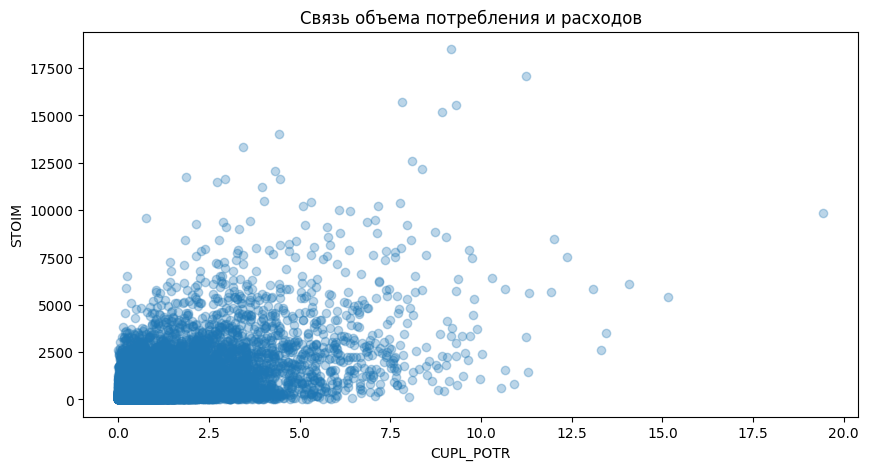

In [36]:
sample_scatter = stat_df.sample(min(10000, len(stat_df)), random_state=42)

plt.scatter(sample_scatter['CUPL_POTR'], sample_scatter['STOIM'], alpha=0.3)
plt.title('Связь объема потребления и расходов')
plt.xlabel('CUPL_POTR')
plt.ylabel('STOIM')
plt.show()

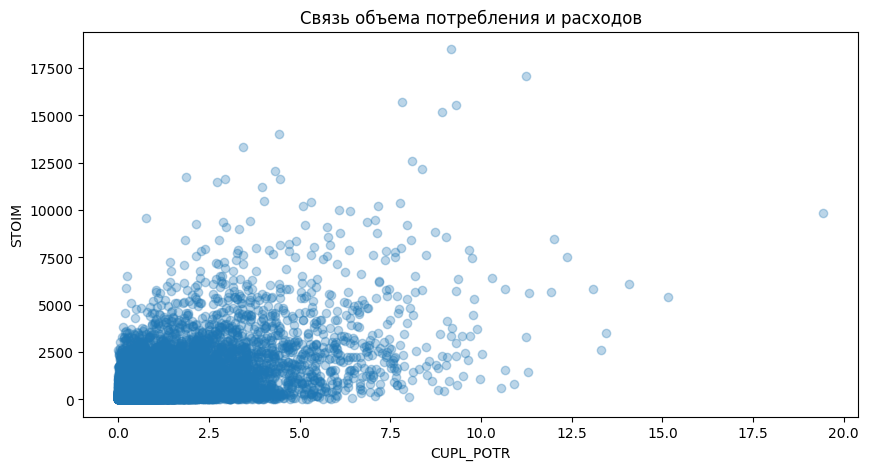

In [37]:
sample_scatter = stat_df.sample(min(10000, len(stat_df)), random_state=42)

plt.scatter(sample_scatter['CUPL_POTR'], sample_scatter['STOIM'], alpha=0.3)
plt.title('Связь объема потребления и расходов')
plt.xlabel('CUPL_POTR')
plt.ylabel('STOIM')
plt.show()

In [38]:
X = stat_df[['CUPL_POTR']]
X = sm.add_constant(X)
y = stat_df['STOIM']

model_simple = sm.OLS(y, X).fit()
print(model_simple.summary())

print("R-squared показывает, какую долю изменчивости расходов объясняет объем потребления.")
print("Если коэффициент при CUPL_POTR положительный и значимый, значит рост объема связан с ростом расходов.")

                            OLS Regression Results                            
Dep. Variable:                  STOIM   R-squared:                       0.250
Model:                            OLS   Adj. R-squared:                  0.250
Method:                 Least Squares   F-statistic:                 8.223e+04
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:04:02   Log-Likelihood:            -2.0823e+06
No. Observations:              246446   AIC:                         4.165e+06
Df Residuals:                  246444   BIC:                         4.165e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        386.3778      3.009    128.424      0.0

In [40]:
reg_df = stat_df.copy()

model_adv = smf.ols(
    formula='STOIM ~ CUPL_POTR + C(Location) + C(Year) + C(Month)',
    data=reg_df
).fit()

print(model_adv.summary())

print("Эта модель учитывает не только объем потребления, но и различия между типами местности и временем.")
print("Так выводы становятся сильнее, чем в простой однофакторной регрессии.")

                            OLS Regression Results                            
Dep. Variable:                  STOIM   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.272
Method:                 Least Squares   F-statistic:                     6140.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:04:36   Log-Likelihood:            -2.0786e+06
No. Observations:              246446   AIC:                         4.157e+06
Df Residuals:                  246430   BIC:                         4.157e+06
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             566.5041    

In [41]:
summary_year = work.groupby('Year').agg(
    total_expense=('STOIM', 'sum'),
    mean_expense=('STOIM', 'mean'),
    mean_volume=('CUPL_POTR', 'mean'),
    mean_price_per_unit=('price_per_unit', 'mean')
).reset_index()

display(summary_year)

,Year,total_expense,mean_expense,mean_volume,mean_price_per_unit
0,2020,140960042.0,876.938939,0.843352,10960.022235
1,2021,170858425.0,887.917563,1.689053,728.965669
2,2022,120327647.0,1142.170356,0.697748,17666.362411


In [42]:
summary_loc = work[work['Location'] != 'Неизвестно'].groupby('Location').agg(
    mean_expense=('STOIM', 'mean'),
    median_expense=('STOIM', 'median'),
    mean_volume=('CUPL_POTR', 'mean'),
    mean_price_per_unit=('price_per_unit', 'mean'),
    count_rows=('STOIM', 'size')
).reset_index()

display(summary_loc)

,Location,mean_expense,median_expense,mean_volume,mean_price_per_unit,count_rows
0,Город,1019.329183,563.0,1.442486,5019.508626,206083
1,Село,597.913262,271.0,0.965631,6704.414280,40363


In [43]:
summary_region = work.groupby('TE').agg(
    mean_expense=('STOIM', 'mean'),
    mean_price_per_unit=('price_per_unit', 'mean'),
    count_rows=('STOIM', 'size')
).reset_index().sort_values('mean_expense', ascending=False)

display(summary_region.head(15))

,TE,mean_expense,mean_price_per_unit,count_rows
0,10,1159.991468,17013.626122,2344
7,33,1136.350217,21271.030526,2073
15,62,1120.681018,19934.255949,1022
2,15,953.206555,7944.369193,31764
10,43,950.846557,8587.747155,27111
8,35,950.145997,7640.387531,35713
9,39,949.978411,7696.399888,30617
12,55,946.746779,7555.616700,36474
4,23,943.450360,8033.836050,17486
1,11,943.294010,8229.917438,29982


In [44]:
results_table = pd.DataFrame({
    'Гипотеза': [
        'Есть различия в расходах между городом и селом',
        'Объем потребления связан с расходами',
        'Есть сезонность расходов',
        'Есть межрегиональные различия'
    ],
    'Проверка': [
        'T-test',
        'Корреляция Пирсона + регрессия',
        'Группировка по месяцам',
        'Группировка по регионам'
    ],
    'Итог': [
        'Смотри p-value T-test',
        'Смотри коэффициент корреляции и регрессию',
        'Смотри график по месяцам',
        'Смотри различия между TE'
    ]
})

display(results_table)

,Гипотеза,Проверка,Итог
0,Есть различия в расходах между городом и селом,T-test,Смотри p-value T-test
1,Объем потребления связан с расходами,Корреляция Пирсона + регрессия,Смотри коэффициент корреляции и регрессию
2,Есть сезонность расходов,Группировка по месяцам,Смотри график по месяцам
3,Есть межрегиональные различия,Группировка по регионам,Смотри различия между TE
